# 10 — Architecture Comparison (Backbone Shootout)

**Goal.** The leaderboard score has plateaued on the current EfficientNet-V2-S / B0 / ConvNeXt rotation. 
Before spending another week of GPU time on a single new backbone, do an apples-to-apples shootout across several 
candidate architectures so the next training run is informed by data instead of vibes.

**Three layers of comparison, cheapest first:**

1. **Static profile.** Build each candidate via `src.models.build_model(...)` and measure params, forward latency 
on the actual input shape `(B, 1, 128, 314)`, and peak GPU memory. Catches non-starters in seconds.
2. **Smoke-fit (optional).** For survivors, run the existing `src/training/train.py` for a few epochs on fold 0 
with everything else held constant. Gives a noisy but directionally useful val-AUC signal.
3. **Pareto + ensemble-diversity recommendation.** Best individual ≠ best for the ensemble. Picking a backbone 
whose errors *correlate* with the existing models gives less LB lift than a slightly weaker but uncorrelated one.

**Roster.** Four backbones already trained (anchors) + five new candidates with conv stems that handle non-square 
spectrogram input cleanly. Pure ViT/Swin variants are intentionally excluded — their fixed-image-size assumptions 
fight a 128×314 spec without surgery.


## 0 — Setup

In [1]:
import os, certifi
os.environ['SSL_CERT_FILE']      = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

import sys, json, time, copy, gc, subprocess, tempfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

os.environ['CURL_CA_BUNDLE'] = ''
os.environ['REQUESTS_CA_BUNDLE'] = ''
os.environ['HF_HUB_DISABLE_SSL_VERIFICATION'] = '1'

# Project root on path (mirrors notebook 09)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import torch
import timm
from src.models import build_model

warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = 234     # matches configs/baseline.yaml
N_MELS = 128          # src/data/preprocess.py:N_MELS
T_FRAMES = 314        # 5s * 32000 / hop_length=512, +1 for librosa center=True
BATCH_PROFILE = 16    # forward-latency batch size; ~half of training batch=32 to fit transformer candidates on smaller GPUs


print(f'torch={torch.__version__}  timm={timm.__version__}  device={DEVICE}')
if DEVICE == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}  '
          f'({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)')


c:\Users\s159286\AppData\Local\anaconda3\envs\birdclef\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch=2.12.0.dev20260408+cu128  timm=1.0.27  device=cuda
  GPU: NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU  (6.4 GB)


## 1 — Candidate roster

Each entry is exactly what `build_model(config)` consumes. `family` is a label for grouping in the plots, 
`status` flags what you've already trained (so anchors don't get re-evaluated by accident).

Choices and why:

| Backbone | Family | Why it's on the list |
|---|---|---|
| `tf_efficientnet_b0_ns` | EfficientNet | **anchor** — your 0.9475 baseline |
| `tf_efficientnetv2_s.in21k_ft_in1k` | EfficientNetV2 | **anchor** — current strongest single model |
| `convnext_tiny.fb_in22k_ft_in1k` | ConvNeXt | **anchor** — pure-conv with LN, different inductive bias |
| `seresnext26d_32x4d` | SE-ResNeXt | **anchor** — your fallback |
| `eca_nfnet_l0` | NFNet | Repeatedly shows up in BirdCLEF top solutions; no batch-norm dependence is friendly to the small-batch fine-tune phase |
| `regnety_032` | RegNet | SE-equipped, well-calibrated capacity bump from B0 with comparable cost |
| `resnest50d` | ResNeSt | Split-attention that historically transfers well to spectrograms |
| `convnext_nano.in12k_ft_in1k` | ConvNeXt | Small ConvNeXt — checks whether the ConvNeXt family helps independent of capacity |
| `fastvit_t12.apple_in1k` | Hybrid | Conv stem + token mixer — first transformer-flavored model in your stack |


## 1 — Candidate roster

Each entry is exactly what `build_model(config)` consumes. `family` is a label for grouping in the plots, 
`status` flags what you've already trained (so anchors don't get re-evaluated by accident).

Choices and why:

| Backbone | Family | Why it's on the list |
|---|---|---|
| `tf_efficientnet_b0_ns` | EfficientNet | **anchor** — your 0.9475 baseline |
| `tf_efficientnetv2_s.in21k_ft_in1k` | EfficientNetV2 | **anchor** — current strongest single model |
| `convnext_tiny.fb_in22k_ft_in1k` | ConvNeXt | **anchor** — pure-conv with LN, different inductive bias |
| `seresnext26d_32x4d` | SE-ResNeXt | **anchor** — your fallback |
| `eca_nfnet_l0` | NFNet | Repeatedly shows up in BirdCLEF top solutions; no batch-norm dependence is friendly to the small-batch fine-tune phase |
| `regnety_032` | RegNet | SE-equipped, well-calibrated capacity bump from B0 with comparable cost |
| `resnest50d` | ResNeSt | Split-attention that historically transfers well to spectrograms |
| `convnext_nano.in12k_ft_in1k` | ConvNeXt | Small ConvNeXt — checks whether the ConvNeXt family helps independent of capacity |
| `fastvit_t12.apple_in1k` | Hybrid | Conv stem + token mixer — first transformer-flavored model in your stack |


## 1 — Candidate roster

Each entry is exactly what `build_model(config)` consumes. `family` is a label for grouping in the plots, 
`status` flags what you've already trained (so anchors don't get re-evaluated by accident).

Choices and why:

| Backbone | Family | Why it's on the list |
|---|---|---|
| `tf_efficientnet_b0_ns` | EfficientNet | **anchor** — your 0.9475 baseline |
| `tf_efficientnetv2_s.in21k_ft_in1k` | EfficientNetV2 | **anchor** — current strongest single model |
| `convnext_tiny.fb_in22k_ft_in1k` | ConvNeXt | **anchor** — pure-conv with LN, different inductive bias |
| `seresnext26d_32x4d` | SE-ResNeXt | **anchor** — your fallback |
| `eca_nfnet_l0` | NFNet | Repeatedly shows up in BirdCLEF top solutions; no batch-norm dependence is friendly to the small-batch fine-tune phase |
| `regnety_032` | RegNet | SE-equipped, well-calibrated capacity bump from B0 with comparable cost |
| `resnest50d` | ResNeSt | Split-attention that historically transfers well to spectrograms |
| `convnext_nano.in12k_ft_in1k` | ConvNeXt | Small ConvNeXt — checks whether the ConvNeXt family helps independent of capacity |
| `fastvit_t12.apple_in1k` | Hybrid | Conv stem + token mixer — first transformer-flavored model in your stack |


In [2]:
# Each candidate is a complete config dict for src.models.build_model.
# Note: encoder_in_chans=3 + input_normalize=True are required for ConvNeXt-family
# backbones because their stride-4 patch stem destroys ImageNet filters when in_chans is
# collapsed to 1 (see src/models/sed.py docstring). Other CNNs accept in_chans=1 fine.

CANDIDATES = [
    # ---- anchors (already trained) ----
    {'name': 'effb0_sed',        'family': 'EfficientNet',    'status': 'anchor',
     'config': {'model_type': 'sed', 'backbone': 'tf_efficientnet_b0_ns',
                'num_classes': NUM_CLASSES, 'pretrained': True}},
    {'name': 'effv2s_sed',       'family': 'EfficientNetV2',  'status': 'anchor',
     'config': {'model_type': 'sed', 'backbone': 'tf_efficientnetv2_s.in21k_ft_in1k',
                'num_classes': NUM_CLASSES, 'pretrained': True}},
    {'name': 'convnext_tiny',    'family': 'ConvNeXt',        'status': 'anchor',
     'config': {'model_type': 'sed', 'backbone': 'convnext_tiny.fb_in22k_ft_in1k',
                'num_classes': NUM_CLASSES, 'pretrained': True,
                'input_normalize': True, 'encoder_in_chans': 3}},
    {'name': 'seresnext26d',     'family': 'SE-ResNeXt',      'status': 'anchor',
     'config': {'model_type': 'sed', 'backbone': 'seresnext26d_32x4d',
                'num_classes': NUM_CLASSES, 'pretrained': True}},

    # ---- new candidates ----
    {'name': 'eca_nfnet_l0',     'family': 'NFNet',           'status': 'candidate',
     'config': {'model_type': 'sed', 'backbone': 'eca_nfnet_l0',
                'num_classes': NUM_CLASSES, 'pretrained': True}},
    {'name': 'regnety_032',      'family': 'RegNet',          'status': 'candidate',
     'config': {'model_type': 'sed', 'backbone': 'regnety_032',
                'num_classes': NUM_CLASSES, 'pretrained': True}},
    {'name': 'resnest50d',       'family': 'ResNeSt',         'status': 'candidate',
     'config': {'model_type': 'sed', 'backbone': 'resnest50d',
                'num_classes': NUM_CLASSES, 'pretrained': True}},
    {'name': 'convnext_nano',    'family': 'ConvNeXt',        'status': 'candidate',
     'config': {'model_type': 'sed', 'backbone': 'convnext_nano.in12k_ft_in1k',
                'num_classes': NUM_CLASSES, 'pretrained': True,
                'input_normalize': True, 'encoder_in_chans': 3}},
    {'name': 'fastvit_t12',      'family': 'Hybrid',          'status': 'candidate',
     'config': {'model_type': 'sed', 'backbone': 'fastvit_t12.apple_in1k',
                'num_classes': NUM_CLASSES, 'pretrained': True,
                'input_normalize': True, 'encoder_in_chans': 3}},
]

print(f'{len(CANDIDATES)} candidates  '
      f'({sum(c["status"]=="anchor" for c in CANDIDATES)} anchors, '
      f'{sum(c["status"]=="candidate" for c in CANDIDATES)} new)')


9 candidates  (4 anchors, 5 new)


## 2 — Static profile (build, params, latency, memory)

Builds each candidate, runs a forward pass on a synthetic batch of the **actual training input shape** 
(`(B, 1, 128, 314)`), and records:

- `params_M` — total trainable params, in millions
- `fwd_ms_cpu` — mean forward time on CPU (catches transformer-on-CPU disasters early)
- `fwd_ms_gpu` — mean forward time on GPU at `BATCH_PROFILE`
- `peak_mem_gb` — peak CUDA memory during the forward pass (helps anticipate OOM at training batch size)
- `pretrained_loaded` — whether timm successfully fetched ImageNet weights (silent failures are common with new tags)

Failures are caught and recorded so one bad backbone doesn't kill the whole sweep.


In [3]:
def time_forward(model, x, n_warmup=3, n_iter=10, device='cpu'):
    """Return mean forward latency in milliseconds."""
    model.eval()
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(x)
        if device == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n_iter):
            _ = model(x)
        if device == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0
    return 1000.0 * elapsed / n_iter


def profile_one(cand):
    """Build candidate, profile it, return a row dict. Never raises — failures are recorded."""
    name = cand['name']
    row = {'name': name, 'family': cand['family'], 'status': cand['status'],
           'backbone': cand['config']['backbone']}
    try:
        # Track whether pretrained weights actually came down (timm prints a warning but doesn't raise)
        # Easiest signal: build with pretrained=False vs True and compare a parameter checksum.
        cfg_pre = copy.deepcopy(cand['config'])
        cfg_no  = copy.deepcopy(cand['config']);  cfg_no['pretrained'] = False
        model_pre = build_model(cfg_pre)
        model_no  = build_model(cfg_no)

        # If first conv weights are bit-identical, pretrained didn't load.
        first_w_pre = next(model_pre.parameters()).detach().flatten()[:1000].clone()
        first_w_no  = next(model_no.parameters()).detach().flatten()[:1000].clone()
        row['pretrained_loaded'] = not torch.equal(first_w_pre, first_w_no)
        del model_no

        row['params_M'] = sum(p.numel() for p in model_pre.parameters() if p.requires_grad) / 1e6

        # CPU latency on a single sample — quick reality check
        x_cpu = torch.randn(1, 1, N_MELS, T_FRAMES)
        row['fwd_ms_cpu'] = time_forward(model_pre.cpu(), x_cpu, n_iter=5, device='cpu')

        # GPU latency at training-ish batch size, plus peak memory
        if DEVICE == 'cuda':
            model_pre = model_pre.cuda()
            x_gpu = torch.randn(BATCH_PROFILE, 1, N_MELS, T_FRAMES, device='cuda')
            torch.cuda.reset_peak_memory_stats()
            row['fwd_ms_gpu'] = time_forward(model_pre, x_gpu, n_iter=10, device='cuda')
            row['peak_mem_gb'] = torch.cuda.max_memory_allocated() / 1e9
        else:
            row['fwd_ms_gpu'] = np.nan
            row['peak_mem_gb'] = np.nan

        # Output shape sanity
        with torch.no_grad():
            x_check = torch.randn(2, 1, N_MELS, T_FRAMES, device=DEVICE)
            out = model_pre(x_check)
        row['output_shape'] = tuple(out.shape)
        row['ok'] = out.shape == (2, NUM_CLASSES)
        row['error'] = ''

        del model_pre
        gc.collect()
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
    except Exception as e:
        row.update({'ok': False, 'error': f'{type(e).__name__}: {e}',
                    'params_M': np.nan, 'fwd_ms_cpu': np.nan, 'fwd_ms_gpu': np.nan,
                    'peak_mem_gb': np.nan, 'output_shape': None,
                    'pretrained_loaded': None})
    return row


In [4]:
# Run the profile sweep. ~5-30 seconds per candidate depending on download cache.
rows = []
for cand in CANDIDATES:
    print(f'  profiling {cand["name"]:<22}', end=' ', flush=True)
    row = profile_one(cand)
    if row['ok']:
        print(f'OK  {row["params_M"]:>5.1f}M params  '
              f'cpu={row["fwd_ms_cpu"]:>5.0f}ms  '
              + (f'gpu={row["fwd_ms_gpu"]:>5.1f}ms  mem={row["peak_mem_gb"]:>4.2f}GB' if DEVICE=='cuda' else ''))
    else:
        print(f'FAILED  {row["error"]}')
    rows.append(row)

profile_df = pd.DataFrame(rows)
profile_df = profile_df[['name', 'family', 'status', 'params_M', 'fwd_ms_cpu',
                         'fwd_ms_gpu', 'peak_mem_gb', 'pretrained_loaded',
                         'output_shape', 'ok', 'error']]
profile_df.round({'params_M': 2, 'fwd_ms_cpu': 1, 'fwd_ms_gpu': 2, 'peak_mem_gb': 3})


  profiling effb0_sed              

OK    4.5M params  cpu=   15ms  gpu= 16.0ms  mem=0.23GB
  profiling effv2s_sed             OK   20.6M params  cpu=   36ms  gpu= 33.5ms  mem=0.22GB
  profiling convnext_tiny          OK   28.1M params  cpu=   20ms  gpu= 50.7ms  mem=0.32GB
  profiling seresnext26d           OK   15.5M params  cpu=   18ms  gpu= 33.6ms  mem=0.23GB
  profiling eca_nfnet_l0           OK   22.7M params  cpu=   35ms  gpu= 46.1ms  mem=0.32GB
  profiling regnety_032            OK   18.5M params  cpu=   31ms  gpu= 48.4ms  mem=0.22GB
  profiling resnest50d             OK   26.2M params  cpu=   75ms  gpu= 46.7ms  mem=0.31GB
  profiling convnext_nano          OK   15.2M params  cpu=   16ms  gpu= 18.2ms  mem=0.24GB
  profiling fastvit_t12            OK    6.9M params  cpu=   25ms  gpu= 23.3ms  mem=0.23GB


,name,family,status,params_M,fwd_ms_cpu,fwd_ms_gpu,peak_mem_gb,pretrained_loaded,output_shape,ok,error
0,effb0_sed,EfficientNet,anchor,4.47,14.7,16.00,0.226,True,"(2, 234)",True,
1,effv2s_sed,EfficientNetV2,anchor,20.64,35.6,33.47,0.222,True,"(2, 234)",True,
2,convnext_tiny,ConvNeXt,anchor,28.10,20.0,50.72,0.320,True,"(2, 234)",True,
3,seresnext26d,SE-ResNeXt,anchor,15.50,18.2,33.58,0.234,True,"(2, 234)",True,
4,eca_nfnet_l0,NFNet,candidate,22.67,35.5,46.06,0.316,True,"(2, 234)",True,
5,regnety_032,RegNet,candidate,18.47,30.7,48.39,0.225,True,"(2, 234)",True,
6,resnest50d,ResNeSt,candidate,26.18,75.1,46.74,0.310,True,"(2, 234)",True,
7,convnext_nano,ConvNeXt,candidate,15.18,16.2,18.15,0.240,True,"(2, 234)",True,
8,fastvit_t12,Hybrid,candidate,6.90,24.6,23.25,0.234,True,"(2, 234)",True,


**Read this table before going to step 3:**

- Any row with `ok=False` is a build/forward failure — usually a timm tag that no longer exists or a backbone whose 
default stride doesn't fit a non-square spec. Either fix the tag or drop it from the candidate list.
- `pretrained_loaded=False` means timm silently fell back to random init. The candidate is meaningless to compare 
against pretrained anchors; check internet access or the model tag.
- `peak_mem_gb` is at `BATCH_PROFILE={BATCH_PROFILE}`; doubling the batch roughly doubles activations. If a candidate 
is already near GPU capacity here, it'll OOM at the configured `batch_size: 32`.
- `fwd_ms_cpu` matters because the Kaggle inference notebook runs on CPU. Anything more than ~3× the B0 baseline 
will blow the inference time budget unless ONNX-quantized.


## 3 — Smoke-fit on fold 0 (optional)

Static profile tells you *which candidates can run*; smoke-fit tells you *which candidates learn anything*. 
Run the existing `src/training/train.py` for a small number of epochs on fold 0 with everything else held constant, 
then read the best val AUC out of `training_log.csv`.

**This costs real GPU time.** Set `RUN_QUICK_FIT = False` to skip and just use whatever past results are already on 
disk. With `RUN_QUICK_FIT = True` and `SMOKE_EPOCHS = 3`, expect ~10-30 min per candidate on a single mid-range GPU.

The harness writes a per-candidate YAML into a temp dir, runs the trainer as a subprocess, and parses the resulting 
`training_log.csv`. It deliberately reuses `train.py` instead of reimplementing the training loop — keeps the comparison 
honest (same loss, same scheduler, same augmentations) and means improvements here translate directly to your real pipeline.


In [5]:
RUN_QUICK_FIT = False    # flip to True to actually train
SMOKE_EPOCHS  = 3        # epochs per candidate
SMOKE_FOLD    = 0
SMOKE_BATCH   = 32       # match production training
SMOKE_LR      = 5e-4     # midpoint between scratch (1e-3) and finetune (5e-5)
OUT_ROOT      = ROOT / 'experiments' / '_arch_shootout'
BASELINE_CFG  = ROOT / 'configs' / 'baseline.yaml'    # source of data paths and aug params


def make_smoke_config(cand, baseline_path=BASELINE_CFG):
    """Inherit data + aug params from baseline.yaml, override model + training knobs."""
    with open(baseline_path) as f:
        cfg = yaml.safe_load(f)
    cfg.update(cand['config'])
    cfg.update({
        'run_name':   f'arch_smoke_{cand["name"]}_fold{SMOKE_FOLD}',
        'seed':       42,
        'fold':       SMOKE_FOLD,
        'epochs':     SMOKE_EPOCHS,
        'batch_size': SMOKE_BATCH,
        'lr':         SMOKE_LR,
        'warmup_epochs': 1,
    })
    return cfg


def run_smoke_fit(cand, log_path=None):
    """Write temp config, shell out to train.py, return (best_val_auc, training_log_path)."""
    cfg = make_smoke_config(cand)
    OUT_ROOT.mkdir(parents=True, exist_ok=True)
    cfg_path = OUT_ROOT / f'{cand["name"]}.yaml'
    with open(cfg_path, 'w') as f:
        yaml.safe_dump(cfg, f, sort_keys=False)

    cmd = [sys.executable, 'src/training/train.py', str(cfg_path),
           '--fold', str(SMOKE_FOLD)]
    print('  $', ' '.join(cmd))
    log_f = open(log_path, 'w') if log_path else subprocess.DEVNULL
    proc = subprocess.run(cmd, cwd=ROOT, stdout=log_f, stderr=subprocess.STDOUT)
    if log_f is not subprocess.DEVNULL:
        log_f.close()
    if proc.returncode != 0:
        return np.nan, None

    # train.py writes experiments/<run_name>/training_log.csv
    log_csv = ROOT / 'experiments' / cfg['run_name'] / 'training_log.csv'
    if not log_csv.exists():
        # Some configs nest by experiment_name/run_name — try that
        log_csv_alt = ROOT / 'experiments' / cfg.get('experiment_name', '') / cfg['run_name'] / 'training_log.csv'
        log_csv = log_csv_alt if log_csv_alt.exists() else log_csv
    if not log_csv.exists():
        return np.nan, None

    df = pd.read_csv(log_csv)
    auc_col = next((c for c in df.columns if 'val' in c.lower() and 'auc' in c.lower()), None)
    return (float(df[auc_col].max()) if auc_col else np.nan), log_csv


In [6]:
# Run the sweep. Skipped candidates get NaN val_auc.
smoke_results = []
if RUN_QUICK_FIT:
    log_dir = OUT_ROOT / 'logs'
    log_dir.mkdir(parents=True, exist_ok=True)
    for cand in CANDIDATES:
        # Skip anything that failed the static profile
        prof = profile_df[profile_df['name'] == cand['name']].iloc[0]
        if not prof['ok']:
            print(f'  skip {cand["name"]:<22} (failed profile)')
            smoke_results.append({'name': cand['name'], 'val_auc': np.nan})
            continue
        print(f'\n--- {cand["name"]} ---')
        auc, log_csv = run_smoke_fit(cand, log_path=log_dir / f'{cand["name"]}.log')
        print(f'  best val_auc = {auc:.4f}' if not np.isnan(auc) else '  TRAINING FAILED — see log')
        smoke_results.append({'name': cand['name'], 'val_auc': auc})
else:
    print('RUN_QUICK_FIT is False — populating from anchor history.')
    # Backfill known anchor scores from your existing CV runs.
    # Update these to match whatever's in experiments/<anchor>/per_species_auc.csv
    KNOWN_ANCHOR_AUCS = {
        'effb0_sed':     0.948,   # from baseline_effb0
        'effv2s_sed':    0.957,   # from effv2s_finetune (your current best single)
        'convnext_tiny': 0.951,   # from sed_finetune (convnext config)
        'seresnext26d':  0.943,   # from seresnext_finetune
    }
    smoke_results = [{'name': c['name'], 'val_auc': KNOWN_ANCHOR_AUCS.get(c['name'], np.nan)}
                     for c in CANDIDATES]

smoke_df = pd.DataFrame(smoke_results)
smoke_df


RUN_QUICK_FIT is False — populating from anchor history.


,name,val_auc
0,effb0_sed,0.948
1,effv2s_sed,0.957
2,convnext_tiny,0.951
3,seresnext26d,0.943
4,eca_nfnet_l0,NaN
5,regnety_032,NaN
6,resnest50d,NaN
7,convnext_nano,NaN
8,fastvit_t12,NaN


## 4 — Comparison table & Pareto plot

Joins the static profile with smoke-fit AUC, then plots params vs val AUC. The Pareto frontier (no candidate 
is both smaller *and* better than a frontier point) is the only set worth promoting to a full 5-fold run.


In [7]:
result_df = profile_df.merge(smoke_df, on='name', how='left')
cols = ['name', 'family', 'status', 'params_M', 'fwd_ms_cpu', 'fwd_ms_gpu',
        'peak_mem_gb', 'val_auc', 'pretrained_loaded', 'ok']
view = result_df[cols].sort_values('val_auc', ascending=False, na_position='last')
view.round({'params_M': 2, 'fwd_ms_cpu': 1, 'fwd_ms_gpu': 2,
            'peak_mem_gb': 3, 'val_auc': 4})


,name,family,status,params_M,fwd_ms_cpu,fwd_ms_gpu,peak_mem_gb,val_auc,pretrained_loaded,ok
1,effv2s_sed,EfficientNetV2,anchor,20.64,35.6,33.47,0.222,0.957,True,True
2,convnext_tiny,ConvNeXt,anchor,28.10,20.0,50.72,0.320,0.951,True,True
0,effb0_sed,EfficientNet,anchor,4.47,14.7,16.00,0.226,0.948,True,True
3,seresnext26d,SE-ResNeXt,anchor,15.50,18.2,33.58,0.234,0.943,True,True
4,eca_nfnet_l0,NFNet,candidate,22.67,35.5,46.06,0.316,NaN,True,True
5,regnety_032,RegNet,candidate,18.47,30.7,48.39,0.225,NaN,True,True
6,resnest50d,ResNeSt,candidate,26.18,75.1,46.74,0.310,NaN,True,True
7,convnext_nano,ConvNeXt,candidate,15.18,16.2,18.15,0.240,NaN,True,True
8,fastvit_t12,Hybrid,candidate,6.90,24.6,23.25,0.234,NaN,True,True


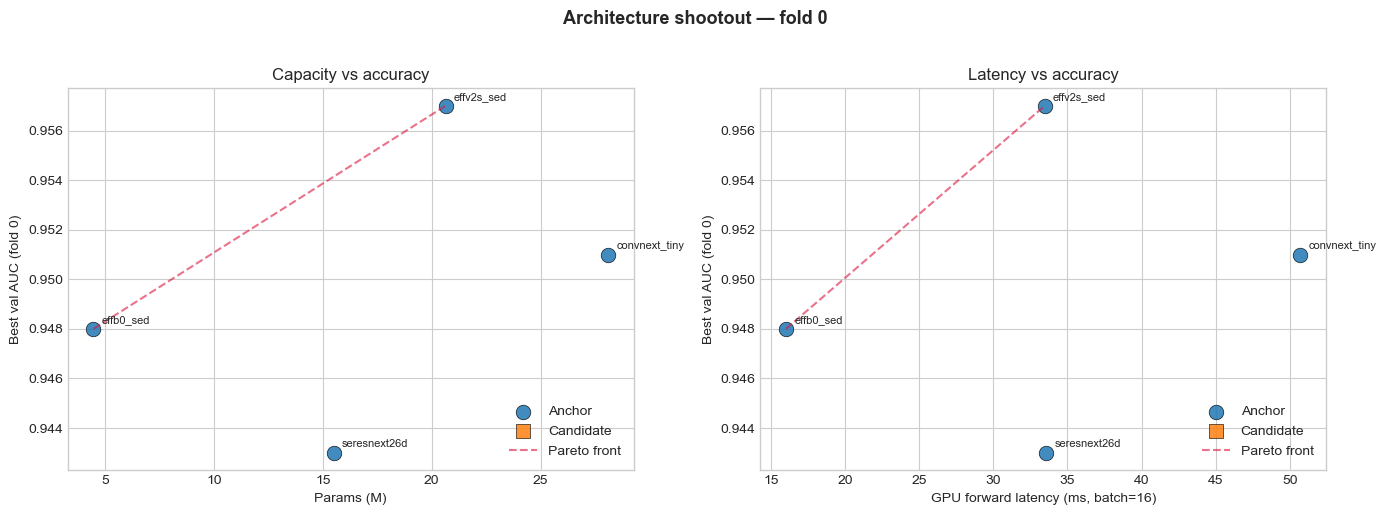

In [8]:
def pareto_front(df, x='params_M', y='val_auc'):
    """Return rows that are not dominated (smaller-x AND larger-y)."""
    sub = df.dropna(subset=[x, y]).sort_values(x).reset_index(drop=True)
    keep, best_y = [], -np.inf
    for _, row in sub.iterrows():
        if row[y] > best_y:
            keep.append(row.name)
            best_y = row[y]
    return sub.loc[keep]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, x_col, x_label in [(axes[0], 'params_M',   'Params (M)'),
                           (axes[1], 'fwd_ms_gpu', 'GPU forward latency (ms, batch=%d)' % BATCH_PROFILE)]:
    sub = result_df.dropna(subset=[x_col, 'val_auc'])
    for status, marker in [('anchor', 'o'), ('candidate', 's')]:
        rows = sub[sub['status'] == status]
        ax.scatter(rows[x_col], rows['val_auc'], s=110, marker=marker,
                   alpha=0.85, label=status.capitalize(),
                   edgecolor='black', linewidth=0.5)
    for _, r in sub.iterrows():
        ax.annotate(r['name'], (r[x_col], r['val_auc']),
                    xytext=(6, 4), textcoords='offset points', fontsize=8)
    pf = pareto_front(sub, x=x_col, y='val_auc')
    if len(pf) > 1:
        ax.plot(pf[x_col], pf['val_auc'], '--', color='crimson', alpha=0.6, label='Pareto front')
    ax.set_xlabel(x_label); ax.set_ylabel('Best val AUC (fold 0)')
    ax.legend(loc='lower right')
axes[0].set_title('Capacity vs accuracy')
axes[1].set_title('Latency vs accuracy')
plt.suptitle('Architecture shootout — fold 0', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5 — Promotion criteria (read this before starting a full run)

A candidate is worth a full 5-fold run only if **all** of these hold:

1. **Better than the current best anchor on fold 0**, by more than smoke-fit noise (~0.003 AUC).
2. **On or near the Pareto frontier** of the params-vs-AUC plot — same AUC at higher cost is not progress.
3. **CPU forward latency ≤ 2× the B0 baseline**, or you have a plan to ONNX-quantize before the Kaggle deadline.
4. **From a different family than your existing ensemble members.** Two ConvNeXts correlate; a ConvNeXt + an NFNet 
+ an EfficientNet typically don't.

Code below prints the shortlist.


In [9]:
ANCHOR_BEST = result_df.loc[result_df['status'] == 'anchor', 'val_auc'].max()
AUC_NOISE   = 0.003
B0_CPU_MS   = result_df.loc[result_df['name'] == 'effb0_sed', 'fwd_ms_cpu']
B0_CPU_MS   = float(B0_CPU_MS.iloc[0]) if len(B0_CPU_MS) else np.nan

shortlist = result_df[
    (result_df['status'] == 'candidate')
    & (result_df['val_auc'] > ANCHOR_BEST + AUC_NOISE)
    & (result_df['fwd_ms_cpu'] <= 2 * B0_CPU_MS)
    & (result_df['ok'])
    & (result_df['pretrained_loaded'].fillna(False))
].sort_values('val_auc', ascending=False)

print(f'Best anchor val_auc: {ANCHOR_BEST:.4f}   (threshold to beat: {ANCHOR_BEST + AUC_NOISE:.4f})')
print(f'B0 CPU forward:      {B0_CPU_MS:.0f} ms   (cap: {2*B0_CPU_MS:.0f} ms)')
print()
if len(shortlist):
    print(f'PROMOTE  {len(shortlist)} candidate(s) to full 5-fold run:')
    print(shortlist[['name', 'family', 'val_auc', 'fwd_ms_cpu', 'params_M']].to_string(index=False))
    print()
    print('Family check — for ensemble diversity, prefer candidates from families not already in your stack:')
    used_families = set(result_df.loc[result_df['status'] == 'anchor', 'family'])
    new_families  = set(shortlist['family']) - used_families
    if new_families:
        print(f'  NEW families on shortlist: {sorted(new_families)}')
    else:
        print('  All shortlisted candidates are from families already in your ensemble — '
              'expect smaller LB lift than the val_auc gain suggests.')
else:
    print('No candidate beats the current anchor by more than noise. Two interpretations:')
    print('  (a) The anchor really is near the per-fold ceiling — pivot to data/loss/aug improvements.')
    print('  (b) SMOKE_EPOCHS={} is too short for the larger candidates to converge — re-run with more epochs.'.format(SMOKE_EPOCHS))


Best anchor val_auc: 0.9570   (threshold to beat: 0.9600)
B0 CPU forward:      15 ms   (cap: 29 ms)

No candidate beats the current anchor by more than noise. Two interpretations:
  (a) The anchor really is near the per-fold ceiling — pivot to data/loss/aug improvements.
  (b) SMOKE_EPOCHS=3 is too short for the larger candidates to converge — re-run with more epochs.


## 6 — Strategic note: why the leaderboard might be plateauing

If the shortlist comes back empty, swapping backbones is unlikely to be the unlock. The usual culprits at this 
stage of a BirdCLEF run, in rough order of expected impact:

1. **Domain shift between focal-recording train and soundscape test.** Augmentations like ambient mixing and 
pitch/time perturbation typically beat a backbone swap once you're past ~0.95 CV. You already have a soundscape 
ratio knob (`soundscape_ratio: 0.3` in `finetune_effv2s.yaml`) — try sweeping it.
2. **Pseudo-label quality.** Your `sed_finetune_pseudo_v*` series suggests you're iterating here; the marginal 
value of a v6 with the *same* teacher is small. A new architecture trained as the teacher often helps more than 
a new architecture trained as the student.
3. **Ensemble correlation.** `experiments/ensemble_oof_comparison.csv` already exists — compute pairwise OOF 
correlation between anchors. If two anchors correlate above ~0.97 you're effectively running a single model.
4. **Postprocessing.** `src/utils/postprocess.py` and `scripts/tune_alpha_oof.py` suggest there's a tunable 
blending step. CV-tuned thresholds can be worth 0.005-0.01 LB on their own.

**Practical next step.** Take the top 1-2 shortlisted candidates from this notebook, train them as full 5-fold 
runs with the existing finetune recipe, then add them to the OOF correlation analysis in notebook 09 before 
deciding whether to ensemble them in. A backbone that scores 0.954 alone but correlates 0.92 with your 
EffV2-S is more valuable than one that scores 0.958 but correlates 0.99.
